In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [24]:
# Load dataset (replace with actual path)
column_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 
                'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 
                'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 
                'num_outbound_cmds', 'is_hot_login', 'is_guest_login', 'count', 'srv_count', 
                'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 
                'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
                'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
                'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
                'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']
data = pd.read_csv("kddcup.data", header=None, names=column_names)

In [25]:
data.shape

(4898431, 42)

In [26]:
data.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,215,45076,0,0,0,0,...,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,162,4528,0,0,0,0,...,1,1.0,0.0,1.00,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,236,1228,0,0,0,0,...,2,1.0,0.0,0.50,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,233,2032,0,0,0,0,...,3,1.0,0.0,0.33,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,239,486,0,0,0,0,...,4,1.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,normal.


In [27]:
# Identify categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']  # Protocol type, service, flag
numeric_cols = [i for i in range(data.shape[1]) if i not in categorical_cols and i != data.shape[1] - 1]

# Convert categorical columns to numerical
le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Split into features and labels
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values   # Labels

# Encode labels to integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Scale features
scaler = StandardScaler()
X[:, numeric_cols] = scaler.fit_transform(X[:, numeric_cols])

In [36]:
# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [37]:
# Reshape data for LSTM (samples, timesteps=1, features)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [ ]:
# Build LSTM model
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(64, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')  # Multiclass output layer
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=10,
                    batch_size=64)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Predictions and metrics
y_pred = np.argmax(model.predict(X_test), axis=-1)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)



Epoch 1/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 85s 2ms/step - accuracy: 0.9978 - loss: 0.0216 - val_accuracy: 0.9996 - val_loss: 0.0014
Epoch 2/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 84s 2ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.9996 - val_loss: 0.0016
Epoch 3/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 84s 2ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9997 - val_loss: 0.0013
Epoch 4/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 83s 2ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9997 - val_loss: 0.0012
Epoch 5/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 83s 2ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9997 - val_loss: 0.0015
Epoch 6/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 83s 2ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.9997 - val_loss: 0.0014
Epoch 7/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 83s 2ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.9997 - val_loss: 0.0019
Epoch 8/10
53577/53577 ━━━━━━━━━━━━━━━━━━━━ 86s 2ms/step - accuracy: 

c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


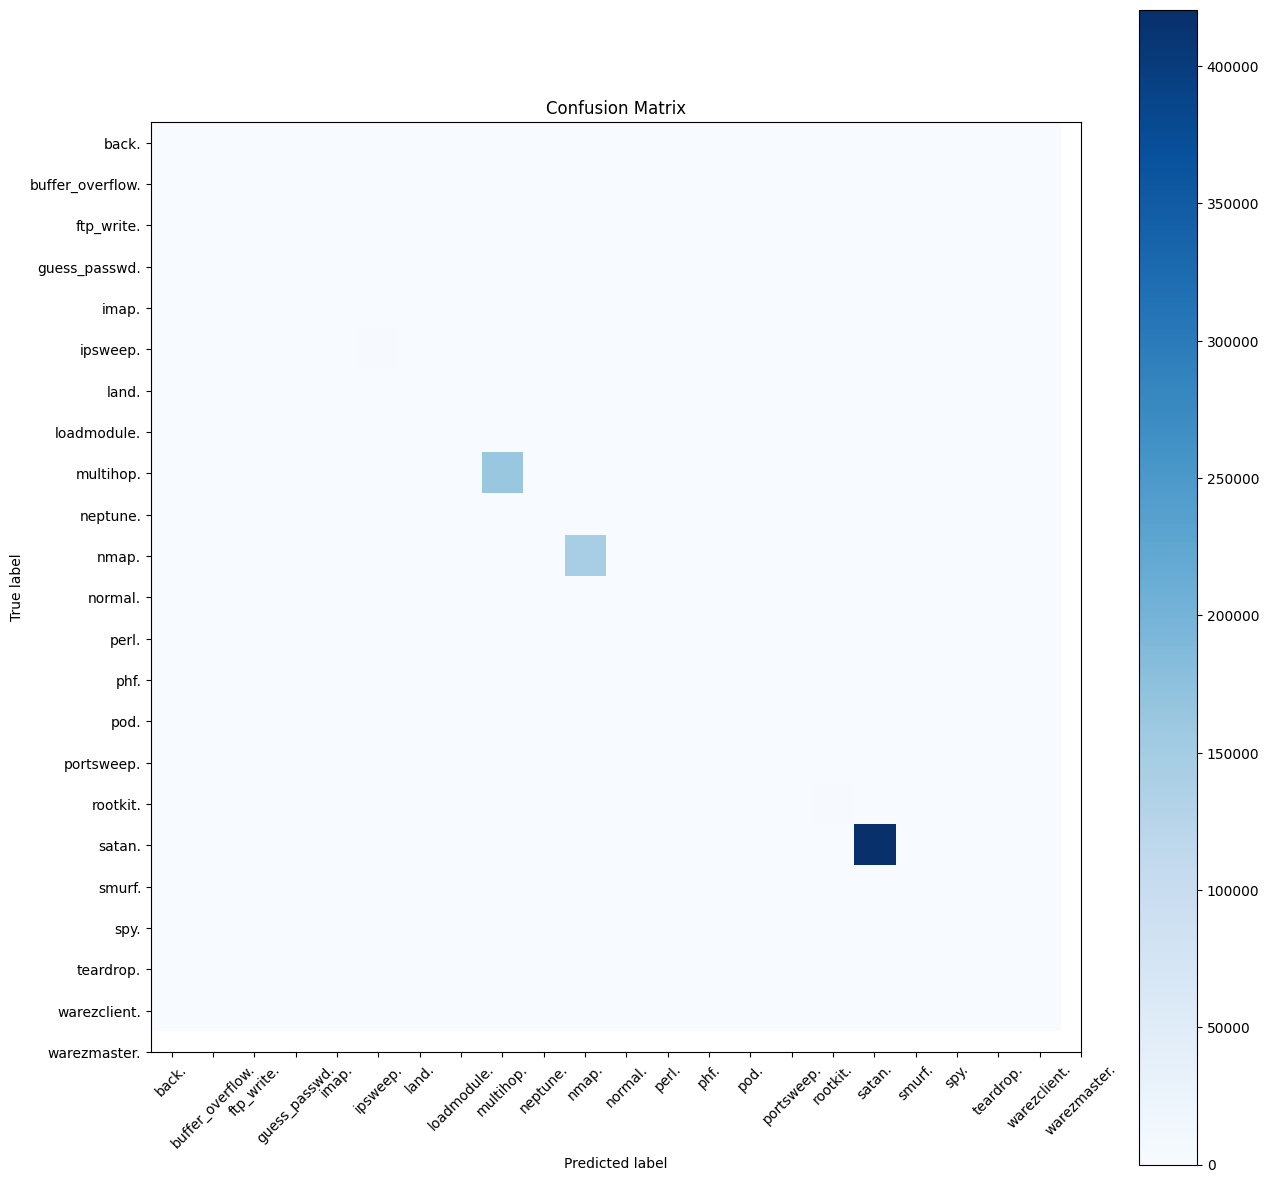

In [40]:
# Plot confusion matrix
plt.figure(figsize=(15, 15))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45)
plt.yticks(tick_marks, label_encoder.classes_)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()



c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


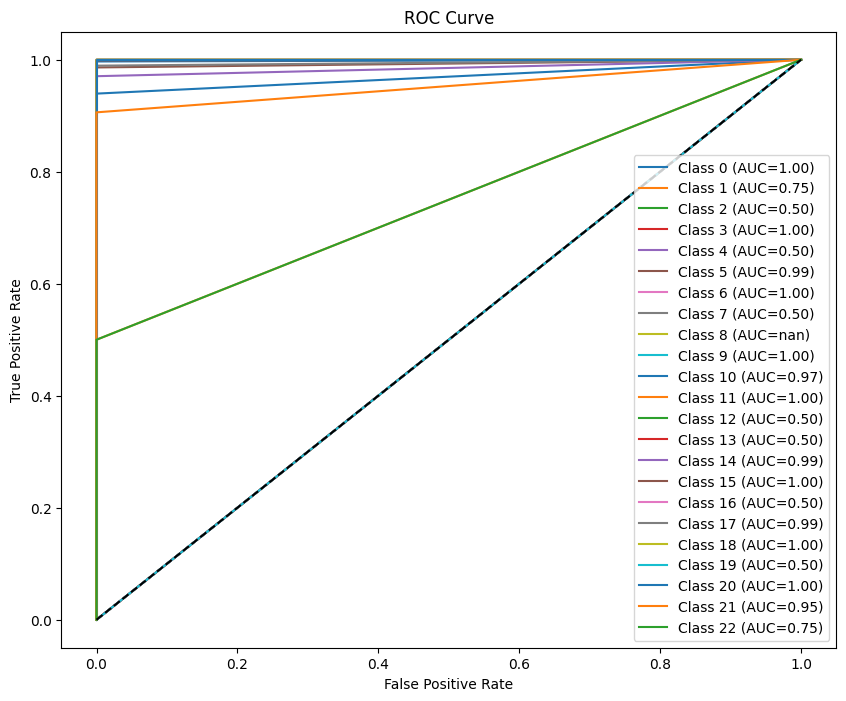

In [44]:
# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), (y_pred == i).astype(int))
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="best")
plt.show()



c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


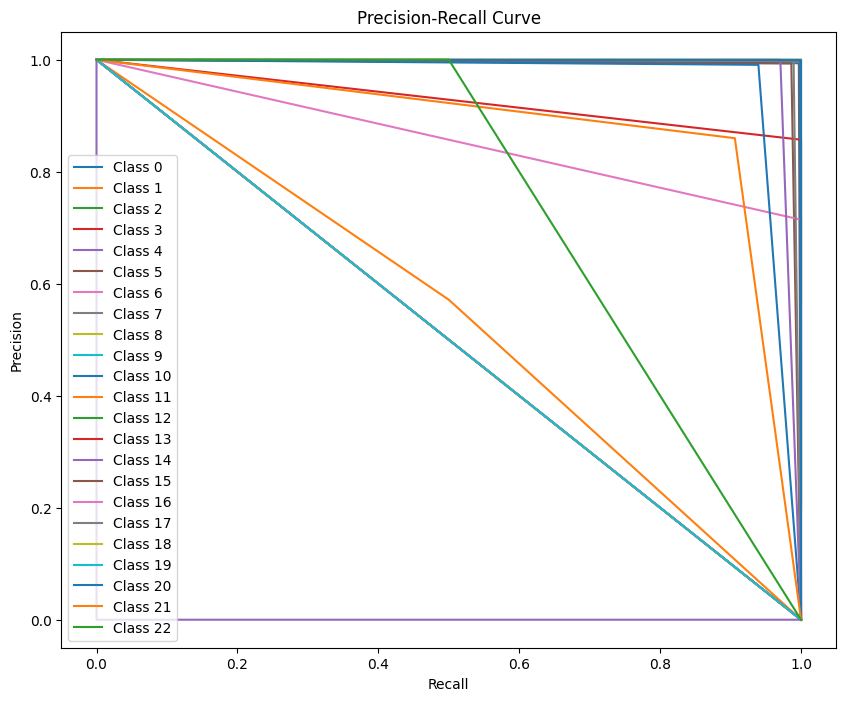

In [45]:
# Plot Precision-Recall curve for each class
plt.figure(figsize=(10, 8))
for i in range(len(np.unique(y))):
    precision, recall, _ = precision_recall_curve((y_test == i).astype(int), (y_pred == i).astype(int))
    plt.plot(recall, precision, label=f"Class {i}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.show()
